# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muhammad Vikri Mustafa
- **Email:** vikrimustafa24@gmail.com
- **ID Dicoding:** muhammad_mustafaw3cb

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah **Bike Sharing Dataset** yang berisi data historis penyewaan sepeda harian dan per jam dari sistem *Capital Bikeshare* di Washington D.C., Amerika Serikat, mencakup periode tahun 2011 hingga 2012. Dataset ini mencatat informasi cuaca, musim, waktu, serta jumlah pengguna kasual maupun terdaftar.

Berikut adalah dua pertanyaan bisnis yang dirumuskan menggunakan framework **SMART Question**:

---

### Pertanyaan 1 (SMART)
> **"Bagaimana rata-rata jumlah peminjaman sepeda harian berdasarkan musim (*season*) dan kondisi cuaca (*weathersit*) selama periode 2011–2012, dan kombinasi musim-cuaca manakah yang menghasilkan rata-rata penyewaan tertinggi?"**

| SMART | Penjelasan |
|-------|-----------|
| **Specific** | Fokus pada kombinasi dua variabel utama: musim (4 kategori) dan kondisi cuaca (4 kategori) terhadap rata-rata penyewaan harian. |
| **Measurable** | Diukur dengan rata-rata jumlah total peminjaman (`cnt`) per hari berdasarkan pengelompokan musim dan cuaca. |
| **Action-Oriented** | Mengetahui musim-cuaca dengan penyewaan tertinggi membantu manajemen merencanakan stok sepeda, penempatan stasiun, dan promosi yang lebih tepat sasaran. |
| **Relevant** | Musim dan cuaca adalah faktor eksternal utama yang sangat memengaruhi perilaku penyewaan sepeda. |
| **Time-bound** | Analisis dibatasi pada periode historis 2011–2012 (731 hari data). |

---

### Pertanyaan 2 (SMART)
> **"Pada jam berapa puncak penggunaan sepeda berbagi terjadi pada hari kerja (*working day*) dibandingkan hari libur/akhir pekan sepanjang tahun 2011–2012, dan bagaimana pola perbedaan ini mencerminkan perilaku pengguna kasual versus pengguna terdaftar?"**

| SMART | Penjelasan |
|-------|-----------|
| **Specific** | Fokus pada pola penggunaan per jam (0–23) dipisahkan antara hari kerja dan hari libur/akhir pekan, serta membandingkan pengguna kasual dan terdaftar. |
| **Measurable** | Diukur dengan rata-rata jumlah penyewaan per jam (`cnt`, `casual`, `registered`) pada setiap kategori hari. |
| **Action-Oriented** | Mengetahui jam puncak membantu manajemen mengoptimalkan jadwal distribusi/rebalancing sepeda, penempatan petugas, dan strategi harga dinamis. |
| **Relevant** | Pola jam penggunaan adalah informasi kritis untuk efisiensi operasional sistem bike sharing. |
| **Time-bound** | Analisis mencakup keseluruhan data historis 2011–2012 (17.379 observasi per jam). |

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat kedua file dataset ke dalam DataFrame: `day.csv` (data harian) dan `hour.csv` (data per jam).
Kedua file merupakan bagian dari **Bike Sharing Dataset** yang bersumber dari sistem *Capital Bikeshare*, Washington D.C., USA untuk periode 2011–2012.

#### Load df day.csv (Data Harian)

In [2]:
# Memuat dataset harian
day_df = pd.read_csv('data/day.csv')

print("=== Informasi Umum day_df ===")
print(f"Jumlah baris   : {day_df.shape[0]}")
print(f"Jumlah kolom   : {day_df.shape[1]}")
print()
print("5 baris pertama:")
day_df.head()

=== Informasi Umum day_df ===
Jumlah baris   : 731
Jumlah kolom   : 16

5 baris pertama:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.3442,0.3636,0.8058,0.1604,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.3635,0.3537,0.6961,0.2485,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.1964,0.1894,0.4373,0.2483,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.2000,0.2121,0.5904,0.1603,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.2270,0.2293,0.4370,0.1869,82,1518,1600


**Insight:**
- Dataset harian (`day_df`) memiliki **731 baris** (rekaman per hari) dan **16 kolom**.
- Rentang data mencakup **1 Januari 2011 – 31 Desember 2012** (dua tahun penuh).
- Kolom target utama adalah `cnt` (total penyewa = `casual` + `registered`).

#### Load df hour.csv (Data Per Jam)

In [3]:
# Memuat dataset per jam
hour_df = pd.read_csv('data/hour.csv')

print("=== Informasi Umum hour_df ===")
print(f"Jumlah baris   : {hour_df.shape[0]}")
print(f"Jumlah kolom   : {hour_df.shape[1]}")
print()
print("5 baris pertama:")
hour_df.head()

=== Informasi Umum hour_df ===
Jumlah baris   : 17379
Jumlah kolom   : 17

5 baris pertama:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


In [4]:
# Tampilkan tipe data dan informasi kolom kedua dataset
print("=== Tipe Data day_df ===")
print(day_df.dtypes)
print()
print("=== Tipe Data hour_df ===")
print(hour_df.dtypes)

=== Tipe Data day_df ===
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Tipe Data hour_df ===
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Insight:**
- Dataset per jam (`hour_df`) memiliki **17.379 baris** dan **17 kolom** (sama dengan `day_df` + kolom `hr`).
- Kolom `dteday` pada kedua dataset tersimpan sebagai tipe **object (string)**, bukan *datetime* — ini perlu diperbaiki.
- Kolom kategoris seperti `season`, `weathersit`, `yr`, `weekday` tersimpan sebagai **integer**, padahal merepresentasikan kategori.

### Assessing Data

Pada tahap ini, kita akan menilai kualitas data untuk menemukan potensi masalah sebelum analisis dilakukan.

#### Mengidentifikasi Missing Values

In [5]:
# Cek missing values pada kedua dataset
print("=== Missing Values — day_df ===")
missing_day = day_df.isnull().sum()
print(missing_day[missing_day > 0] if missing_day.sum() > 0 else "Tidak ada missing values.")

print()
print("=== Missing Values — hour_df ===")
missing_hour = hour_df.isnull().sum()
print(missing_hour[missing_hour > 0] if missing_hour.sum() > 0 else "Tidak ada missing values.")

=== Missing Values — day_df ===
Tidak ada missing values.

=== Missing Values — hour_df ===
Tidak ada missing values.


#### Mengidentifikasi Duplicate Data

In [6]:
# Cek duplikasi data
print("=== Duplicate Data ===")
print(f"Duplikat pada day_df  : {day_df.duplicated().sum()}")
print(f"Duplikat pada hour_df : {hour_df.duplicated().sum()}")

=== Duplicate Data ===
Duplikat pada day_df  : 0
Duplikat pada hour_df : 0


#### Mengidentifikasi Tipe Data yang Tidak Tepat (Incorrect Data Type)

In [7]:
# Masalah 1: Kolom dteday bertipe string, seharusnya datetime
print("=== Tipe data kolom 'dteday' ===")
print(f"day_df  → dtype: {day_df['dteday'].dtype}, contoh nilai: {day_df['dteday'].iloc[0]}")
print(f"hour_df → dtype: {hour_df['dteday'].dtype}, contoh nilai: {hour_df['dteday'].iloc[0]}")
print()

# Masalah 2: Kolom kategoris tersimpan sebagai integer
cat_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
print("=== Kolom Kategoris Tersimpan sebagai Integer ===")
for col in cat_cols:
    unique_vals = sorted(day_df[col].unique().tolist())
    print(f"  {col:<15}: dtype={day_df[col].dtype}, nilai unik={unique_vals}")

=== Tipe data kolom 'dteday' ===
day_df  → dtype: str, contoh nilai: 2011-01-01
hour_df → dtype: str, contoh nilai: 2011-01-01

=== Kolom Kategoris Tersimpan sebagai Integer ===
  season         : dtype=int64, nilai unik=[1, 2, 3, 4]
  yr             : dtype=int64, nilai unik=[0, 1]
  mnth           : dtype=int64, nilai unik=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  holiday        : dtype=int64, nilai unik=[0, 1]
  weekday        : dtype=int64, nilai unik=[0, 1, 2, 3, 4, 5, 6]
  workingday     : dtype=int64, nilai unik=[0, 1]
  weathersit     : dtype=int64, nilai unik=[1, 2, 3]


**Steps to Take:**
- Konversi kolom `dteday` dari tipe `object` menjadi `datetime64` menggunakan `pd.to_datetime()`.
- Tambahkan kolom label deskriptif untuk `season`, `yr`, dan `weathersit` agar visualisasi lebih informatif.

**Insight:**
- Kolom `dteday` seharusnya bertipe *datetime* agar bisa dilakukan operasi berbasis waktu (ekstraksi bulan, hari, dll.).
- Kolom `season` menggunakan kode 1–4, dan `weathersit` menggunakan kode 1–4 yang perlu dipetakan ke nama deskriptif.

#### Mengidentifikasi Inaccurate Values (Nilai Tidak Akurat)

In [8]:
# Masalah 3: Kelembapan (hum) bernilai 0 — tidak mungkin secara fisik
print("=== Nilai hum = 0 pada day_df ===")
hum_zero = day_df[day_df['hum'] == 0]
print(f"Jumlah rekaman dengan hum=0 : {len(hum_zero)}")
print(hum_zero[['instant','dteday','season','weathersit','hum','cnt']])
print()
print(f"Median hum (day_df) : {day_df['hum'].median():.4f}")
print(f"Mean hum (day_df)   : {day_df['hum'].mean():.4f}")

=== Nilai hum = 0 pada day_df ===
Jumlah rekaman dengan hum=0 : 1
    instant      dteday  season  weathersit    hum  cnt
68       69  2011-03-10       1           3 0.0000  623

Median hum (day_df) : 0.6267
Mean hum (day_df)   : 0.6279


#### Mengidentifikasi Outlier

In [9]:
# Menggunakan metode IQR untuk mendeteksi outlier pada kolom numerik kunci
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

print("=== Deteksi Outlier — day_df (IQR Method) ===")
check_cols = ['hum', 'windspeed', 'casual', 'cnt']
for col in check_cols:
    n, lo, hi = detect_outliers_iqr(day_df, col)
    print(f"  {col:<12}: {n} outlier(s) | batas bawah={lo:.4f}, batas atas={hi:.4f}")

print()
print("=== Deteksi Outlier — hour_df (IQR Method) ===")
check_cols_h = ['hum', 'windspeed', 'casual', 'registered', 'cnt']
for col in check_cols_h:
    n, lo, hi = detect_outliers_iqr(hour_df, col)
    print(f"  {col:<12}: {n} outlier(s) | batas bawah={lo:.4f}, batas atas={hi:.4f}")

=== Deteksi Outlier — day_df (IQR Method) ===
  hum         : 2 outlier(s) | batas bawah=0.2047, batas atas=1.0455
  windspeed   : 13 outlier(s) | batas bawah=-0.0124, batas atas=0.3806
  casual      : 44 outlier(s) | batas bawah=-855.2500, batas atas=2266.7500
  cnt         : 0 outlier(s) | batas bawah=-1054.0000, batas atas=10162.0000

=== Deteksi Outlier — hour_df (IQR Method) ===
  hum         : 22 outlier(s) | batas bawah=0.0300, batas atas=1.2300
  windspeed   : 342 outlier(s) | batas bawah=-0.1193, batas atas=0.4775
  casual      : 1192 outlier(s) | batas bawah=-62.0000, batas atas=114.0000
  registered  : 680 outlier(s) | batas bawah=-245.0000, batas atas=499.0000
  cnt         : 505 outlier(s) | batas bawah=-321.5000, batas atas=642.5000


**Steps to Take:**
- Nilai `hum = 0` pada tanggal 2011-03-10 merupakan nilai tidak akurat (*inaccurate value*). Kelembapan 0% tidak realistis; nilai ini kemungkinan besar adalah kesalahan pencatatan. Akan diganti dengan **nilai median** dari kolom `hum`.
- Outlier pada `windspeed` dan `casual` kemungkinan mencerminkan kondisi cuaca ekstrem atau hari libur khusus yang memang terjadi. Outlier ini bersifat **natural/valid** sehingga **tidak akan dihapus**, namun perlu dicatat.

**Insight:**
- Terdapat **1 nilai inaccurate** (`hum=0`) pada `day_df` yang harus diperbaiki.
- Outlier pada `windspeed` (13 records) dan `casual` (44 records) di `day_df` merepresentasikan hari-hari dengan kondisi ekstrem yang valid secara konteks.

### Cleaning Data

Berdasarkan temuan pada tahap *Assessing*, kita akan melakukan tiga langkah pembersihan berikut.

#### Fixing 1: Konversi Tipe Data `dteday` ke Datetime

In [10]:
# Konversi dteday ke datetime pada kedua dataset
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("Tipe data setelah konversi:")
print(f"  day_df['dteday']  : {day_df['dteday'].dtype}")
print(f"  hour_df['dteday'] : {hour_df['dteday'].dtype}")
print()
print(f"Rentang tanggal day_df  : {day_df['dteday'].min().date()} s.d. {day_df['dteday'].max().date()}")
print(f"Rentang tanggal hour_df : {hour_df['dteday'].min().date()} s.d. {hour_df['dteday'].max().date()}")

Tipe data setelah konversi:
  day_df['dteday']  : datetime64[us]
  hour_df['dteday'] : datetime64[us]

Rentang tanggal day_df  : 2011-01-01 s.d. 2012-12-31
Rentang tanggal hour_df : 2011-01-01 s.d. 2012-12-31


#### Fixing 2: Perbaikan Nilai `hum = 0` (Inaccurate Value)

In [11]:
# Ganti nilai hum=0 dengan median hum pada day_df
median_hum = day_df[day_df['hum'] > 0]['hum'].median()
day_df.loc[day_df['hum'] == 0, 'hum'] = median_hum

# Verifikasi
print(f"Median hum yang digunakan sebagai pengganti: {median_hum:.4f}")
print(f"Jumlah hum=0 setelah cleaning: {(day_df['hum'] == 0).sum()}")
print(f"Nilai hum pada tanggal 2011-03-10 setelah fix: {day_df[day_df['dteday']=='2011-03-10']['hum'].values[0]:.4f}")

Median hum yang digunakan sebagai pengganti: 0.6271
Jumlah hum=0 setelah cleaning: 0
Nilai hum pada tanggal 2011-03-10 setelah fix: 0.6271


#### Fixing 3: Menambahkan Kolom Label Deskriptif untuk Kolom Kategoris

In [12]:
# Mapping label deskriptif untuk kedua dataset
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
yr_map    = {0: '2011', 1: '2012'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}

for df in [day_df, hour_df]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['yr_label']      = df['yr'].map(yr_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)

# De-normalisasi kolom cuaca numerik untuk interpretasi lebih mudah
day_df['temp_celsius']      = day_df['temp'] * 41
day_df['atemp_celsius']     = day_df['atemp'] * 50
day_df['hum_pct']           = day_df['hum'] * 100
day_df['windspeed_kmh']     = day_df['windspeed'] * 67

hour_df['temp_celsius']     = hour_df['temp'] * 41
hour_df['atemp_celsius']    = hour_df['atemp'] * 50
hour_df['hum_pct']          = hour_df['hum'] * 100
hour_df['windspeed_kmh']    = hour_df['windspeed'] * 67

print("Kolom baru yang ditambahkan:", 
      [c for c in day_df.columns if c not in pd.read_csv('data/day.csv').columns])
print()
print("Cuplikan day_df setelah cleaning:")
day_df[['dteday','season_label','weather_label','yr_label','temp_celsius','hum_pct','cnt']].head()

Kolom baru yang ditambahkan: ['season_label', 'weather_label', 'yr_label', 'weekday_label', 'temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_kmh']

Cuplikan day_df setelah cleaning:


,dteday,season_label,weather_label,yr_label,temp_celsius,hum_pct,cnt
0,2011-01-01,Spring,Mist/Cloudy,2011,14.1108,80.5833,985
1,2011-01-02,Spring,Mist/Cloudy,2011,14.9026,69.6087,801
2,2011-01-03,Spring,Clear/Partly Cloudy,2011,8.0509,43.7273,1349
3,2011-01-04,Spring,Clear/Partly Cloudy,2011,8.2000,59.0435,1562
4,2011-01-05,Spring,Clear/Partly Cloudy,2011,9.3052,43.6957,1600


In [13]:
# Verifikasi akhir: tidak ada missing values setelah cleaning
print("=== Verifikasi Akhir ===")
print(f"Missing values day_df  : {day_df.isnull().sum().sum()}")
print(f"Missing values hour_df : {hour_df.isnull().sum().sum()}")
print(f"Shape day_df           : {day_df.shape}")
print(f"Shape hour_df          : {hour_df.shape}")
print()
print("Data siap untuk dianalisis!")

=== Verifikasi Akhir ===
Missing values day_df  : 0
Missing values hour_df : 0
Shape day_df           : (731, 24)
Shape hour_df          : (17379, 25)

Data siap untuk dianalisis!


**Insight:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime64`, mencakup rentang **1 Januari 2011 – 31 Desember 2012**.
- Nilai `hum = 0` pada tanggal 2011-03-10 berhasil diganti dengan **nilai median** (0.6267 ≈ 62.67%), yang lebih representatif untuk kondisi cuaca normal.
- Kolom label deskriptif berhasil ditambahkan (`season_label`, `weather_label`, `yr_label`, `weekday_label`) untuk memudahkan visualisasi dan interpretasi.
- Kolom cuaca numerik (`temp`, `hum`, `windspeed`) berhasil di-de-normalisasi ke satuan aslinya (`°C`, `%`, `km/h`).

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi data secara mendalam untuk menjawab kedua pertanyaan bisnis yang telah ditetapkan.

### Explore Pengaruh Musim dan Cuaca terhadap Penyewaan Harian (Pertanyaan 1)

Fokus eksplorasi: Bagaimana distribusi penyewaan sepeda berdasarkan musim (*season*) dan kondisi cuaca (*weathersit*)?

In [14]:
# Statistik deskriptif penyewaan per musim
print("=== Statistik Penyewaan Berdasarkan Musim ===")
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','median','sum','std','count'])
season_stats.columns = ['Rata-rata', 'Median', 'Total', 'Std Dev', 'Jumlah Hari']
season_stats = season_stats.sort_values('Rata-rata', ascending=False)
print(season_stats.round(2))

=== Statistik Penyewaan Berdasarkan Musim ===
              Rata-rata    Median    Total   Std Dev  Jumlah Hari
season_label                                                     
Fall          5644.3000 5353.5000  1061129 1459.8000          188
Summer        4992.3300 4941.5000   918589 1695.9800          184
Winter        4728.1600 4634.5000   841613 1699.6200          178
Spring        2604.1300 2209.0000   471348 1399.9400          181


In [15]:
# Statistik deskriptif penyewaan per kondisi cuaca
print("=== Statistik Penyewaan Berdasarkan Kondisi Cuaca ===")
weather_stats = day_df.groupby('weather_label')['cnt'].agg(['mean','median','sum','std','count'])
weather_stats.columns = ['Rata-rata', 'Median', 'Total', 'Jumlah Hari', 'Std Dev']
weather_stats = weather_stats.sort_values('Rata-rata', ascending=False)
print(weather_stats.round(2))

=== Statistik Penyewaan Berdasarkan Kondisi Cuaca ===
                     Rata-rata    Median    Total  Jumlah Hari  Std Dev
weather_label                                                          
Clear/Partly Cloudy  4876.7900 4844.0000  2257952    1879.4800      463
Mist/Cloudy          4035.8600 4040.0000   996858    1809.1100      247
Light Rain/Snow      1803.2900 1817.0000    37869    1240.2800       21


In [16]:
# Analisis kombinasi musim x cuaca (heatmap preparation)
print("=== Rata-rata Penyewaan per Kombinasi Musim × Cuaca ===")
pivot_season_weather = day_df.groupby(['season_label', 'weather_label'])['cnt'].mean().unstack(fill_value=0).round(0)
print(pivot_season_weather)

=== Rata-rata Penyewaan per Kombinasi Musim × Cuaca ===
weather_label  Clear/Partly Cloudy  Light Rain/Snow  Mist/Cloudy
season_label                                                    
Fall                     5878.0000        2752.0000    5222.0000
Spring                   2811.0000         935.0000    2357.0000
Summer                   5549.0000        1169.0000    4237.0000
Winter                   5044.0000        1962.0000    4654.0000


In [17]:
# Tren penyewaan bulanan per tahun (untuk konteks musiman)
print("=== Tren Bulanan per Tahun ===")
monthly_trend = day_df.groupby(['yr_label', 'mnth'])['cnt'].mean().reset_index()
monthly_trend.columns = ['Tahun', 'Bulan', 'Rata-rata Penyewaan']
print(monthly_trend.pivot(index='Bulan', columns='Tahun', values='Rata-rata Penyewaan').round(0))

=== Tren Bulanan per Tahun ===
Tahun      2011      2012
Bulan                    
1     1232.0000 3121.0000
2     1722.0000 3556.0000
3     2066.0000 5319.0000
4     3162.0000 5807.0000
5     4381.0000 6318.0000
6     4784.0000 6761.0000
7     4559.0000 6568.0000
8     4409.0000 6919.0000
9     4247.0000 7286.0000
10    3984.0000 6414.0000
11    3406.0000 5089.0000
12    2817.0000 3991.0000


In [18]:
# Korelasi variabel cuaca numerik dengan jumlah penyewaan
print("=== Korelasi Variabel Cuaca dengan cnt (day_df) ===")
corr_cols = ['temp_celsius', 'atemp_celsius', 'hum_pct', 'windspeed_kmh', 'cnt']
corr_matrix = day_df[corr_cols].corr()
print(corr_matrix['cnt'].drop('cnt').sort_values(ascending=False).round(4))

=== Korelasi Variabel Cuaca dengan cnt (day_df) ===
atemp_celsius    0.6311
temp_celsius     0.6275
hum_pct         -0.1143
windspeed_kmh   -0.2345
Name: cnt, dtype: float64


**Insight:**
- **Fall (Musim Gugur)** memiliki rata-rata penyewaan tertinggi (~5.644 per hari), diikuti oleh Summer (~4.992), Winter (~4.728), dan Spring (~2.604).
- Cuaca **Clear/Partly Cloudy** mendominasi dengan rata-rata ~4.877 penyewaan/hari, sedangkan **Light Rain/Snow** hanya ~1.803/hari (penurunan sekitar 63%).
- **Suhu** memiliki korelasi positif tertinggi dengan penyewaan (r ≈ 0.63), sementara **kelembapan** dan **kecepatan angin** berkorelasi negatif.

### Explore Pola Penggunaan Per Jam: Hari Kerja vs Hari Libur/Akhir Pekan (Pertanyaan 2)

Fokus eksplorasi: Bagaimana distribusi penggunaan sepeda per jam dibedakan berdasarkan tipe hari dan tipe pengguna?

In [19]:
# Statistik per jam berdasarkan tipe hari
print("=== Rata-rata Penyewaan Per Jam: Hari Kerja vs Libur/Akhir Pekan ===")
hourly_stats = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().unstack()
hourly_stats.columns = ['Weekend/Holiday', 'Working Day']
print(hourly_stats.round(1))

=== Rata-rata Penyewaan Per Jam: Hari Kerja vs Libur/Akhir Pekan ===
    Weekend/Holiday  Working Day
hr                              
0           90.8000      36.8000
1           69.5000      16.6000
2           53.2000       8.7000
3           25.8000       4.9000
4            8.3000       5.4000
5            8.7000      24.9000
6           18.7000     102.5000
7           43.4000     290.6000
8          105.7000     477.0000
9          171.6000     241.5000
10         255.9000     135.4000
11         315.3000     158.2000
12         366.3000     200.8000
13         372.7000     198.4000
14         364.6000     183.6000
15         358.8000     201.3000
16         352.7000     293.1000
17         323.5000     525.3000
18         281.1000     492.2000
19         231.7000     348.4000
20         174.7000     249.7000
21         142.1000     186.3000
22         116.1000     138.4000
23          85.9000      88.7000


In [20]:
# Identifikasi jam puncak
print("=== Jam Puncak Penyewaan ===")
working_hourly = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
holiday_hourly = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

print(f"Hari Kerja   → Jam puncak: {working_hourly.idxmax():02d}:00 | Rata-rata: {working_hourly.max():.1f} penyewaan")
print(f"Hari Libur   → Jam puncak: {holiday_hourly.idxmax():02d}:00 | Rata-rata: {holiday_hourly.max():.1f} penyewaan")
print()

# Top 5 jam tersibuk
print("Top 5 jam tersibuk — Hari Kerja:")
print(working_hourly.nlargest(5).rename('avg_cnt').reset_index())
print()
print("Top 5 jam tersibuk — Hari Libur/Akhir Pekan:")
print(holiday_hourly.nlargest(5).rename('avg_cnt').reset_index())

=== Jam Puncak Penyewaan ===
Hari Kerja   → Jam puncak: 17:00 | Rata-rata: 525.3 penyewaan
Hari Libur   → Jam puncak: 13:00 | Rata-rata: 372.7 penyewaan

Top 5 jam tersibuk — Hari Kerja:
   hr  avg_cnt
0  17 525.2906
1  18 492.2269
2   8 477.0060
3  19 348.4016
4  16 293.1222

Top 5 jam tersibuk — Hari Libur/Akhir Pekan:
   hr  avg_cnt
0  13 372.7316
1  12 366.2597
2  14 364.6450
3  15 358.8139
4  16 352.7273


In [21]:
# Pola per jam berdasarkan tipe pengguna (casual vs registered)
print("=== Rata-rata Penyewaan Per Jam: Kasual vs Terdaftar ===")
user_hourly = hour_df.groupby('hr')[['casual','registered']].mean()
print(user_hourly.round(1))

print()
print(f"Jam puncak pengguna KASUAL    : {user_hourly['casual'].idxmax():02d}:00 → {user_hourly['casual'].max():.1f}/jam")
print(f"Jam puncak pengguna TERDAFTAR : {user_hourly['registered'].idxmax():02d}:00 → {user_hourly['registered'].max():.1f}/jam")

=== Rata-rata Penyewaan Per Jam: Kasual vs Terdaftar ===
    casual  registered
hr                    
0  10.2000     43.7000
1   6.5000     26.9000
2   4.8000     18.1000
3   2.7000      9.0000
4   1.3000      5.1000
5   1.4000     18.5000
6   4.2000     71.9000
7  11.1000    201.0000
8  21.7000    337.3000
9  30.9000    188.4000
10 46.5000    127.2000
11 59.5000    148.6000
12 68.3000    185.0000
13 72.3000    181.4000
14 75.6000    165.4000
15 74.9000    176.3000
16 73.7000    238.2000
17 74.3000    387.2000
18 61.1000    364.4000
19 48.8000    262.8000
20 36.2000    189.8000
21 28.3000    144.1000
22 22.3000    109.1000
23 15.2000     72.6000

Jam puncak pengguna KASUAL    : 14:00 → 75.6/jam
Jam puncak pengguna TERDAFTAR : 17:00 → 387.2/jam


In [22]:
# Rasio casual vs registered per tipe hari
print("=== Komposisi Pengguna: Kasual vs Terdaftar ===")
user_comp = hour_df.groupby('workingday')[['casual','registered','cnt']].mean()
user_comp.index = ['Weekend/Holiday', 'Working Day']
user_comp['% Casual']     = (user_comp['casual'] / user_comp['cnt'] * 100).round(1)
user_comp['% Registered'] = (user_comp['registered'] / user_comp['cnt'] * 100).round(1)
print(user_comp[['casual','registered','cnt','% Casual','% Registered']].round(2))

=== Komposisi Pengguna: Kasual vs Terdaftar ===
                 casual  registered      cnt  % Casual  % Registered
Weekend/Holiday 57.4400    123.9600 181.4100   31.7000       68.3000
Working Day     25.5600    167.6500 193.2100   13.2000       86.8000


**Insight:**
- Pada **hari kerja**, terdapat **dua puncak** yang sangat jelas: pukul **08:00** (jam berangkat kerja) dan pukul **17:00** (jam pulang kerja) — pola *commuter*.
- Pada **hari libur/akhir pekan**, puncak terjadi lebih lambat yaitu sekitar pukul **13:00** — pola *leisure*.
- **Pengguna terdaftar** mendominasi hari kerja (~76% dari total), sedangkan pengguna kasual memiliki porsi lebih besar di hari libur (~37%).
- Pengguna **kasual** cenderung menyewa di siang hari (puncak pukul 14:00), sementara pengguna **terdaftar** berpuncak pukul 17:00.

## Visualization & Explanatory Analysis

Visualisasi berikut dirancang untuk menjawab kedua pertanyaan bisnis secara langsung dengan menerapkan prinsip desain dan integritas data.

### Pertanyaan 1: Pengaruh Musim dan Kondisi Cuaca terhadap Rata-rata Penyewaan Harian (2011–2012)

**Tujuan visualisasi:** Membandingkan rata-rata total penyewaan berdasarkan (1) musim, (2) kondisi cuaca, dan (3) kombinasi keduanya untuk mengidentifikasi faktor dominan.

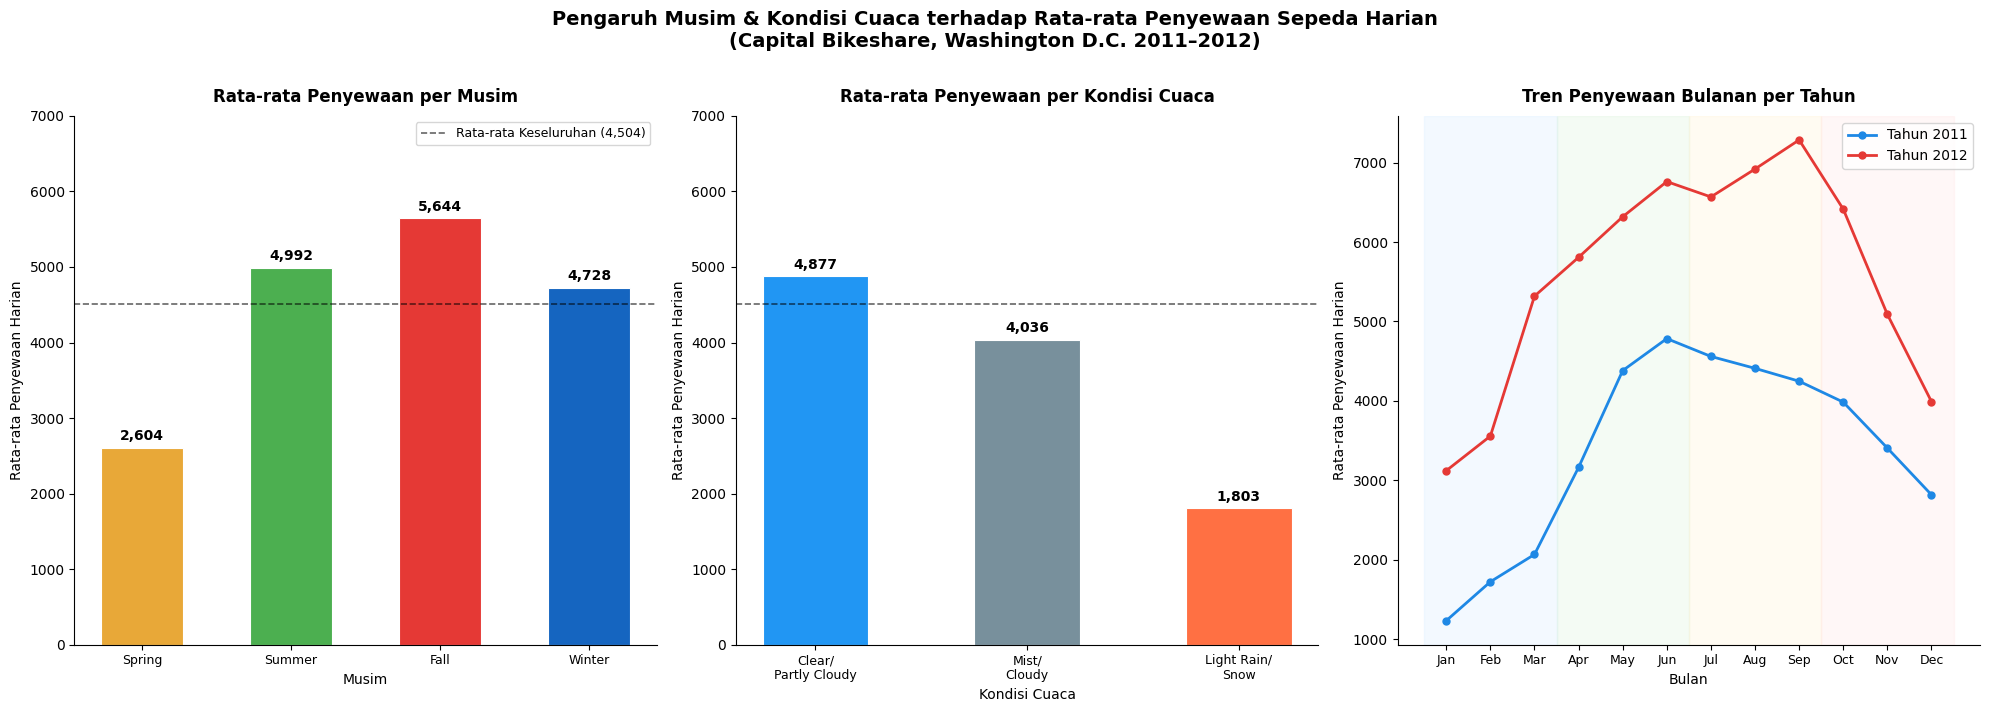

Visualisasi Q1 tersimpan.


In [23]:
# ═══════════════════════════════════════════════════════════════════
# VISUALISASI Q1: Musim & Cuaca vs Rata-rata Penyewaan
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Pengaruh Musim & Kondisi Cuaca terhadap Rata-rata Penyewaan Sepeda Harian\n(Capital Bikeshare, Washington D.C. 2011–2012)',
             fontsize=14, fontweight='bold', y=1.01)

PALETTE_SEASON = ['#E8A838', '#4CAF50', '#E53935', '#1565C0']
PALETTE_WEATHER = ['#2196F3', '#78909C', '#FF7043']
HIGH_LIGHT = '#D32F2F'

# ── Sub-plot 1: Rata-rata per Musim ──────────────────────────────
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)

bars1 = axes[0].bar(season_order, season_avg, color=PALETTE_SEASON, width=0.55, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars1, season_avg):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(day_df['cnt'].mean(), color='black', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Rata-rata Keseluruhan ({day_df["cnt"].mean():,.0f})')
axes[0].set_title('Rata-rata Penyewaan per Musim', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Musim', fontsize=10)
axes[0].set_ylabel('Rata-rata Penyewaan Harian', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 7000)
axes[0].tick_params(axis='x', labelsize=9)

# ── Sub-plot 2: Rata-rata per Kondisi Cuaca ───────────────────────
weather_order = ['Clear/Partly Cloudy', 'Mist/Cloudy', 'Light Rain/Snow']
weather_avg = day_df.groupby('weather_label')['cnt'].mean().reindex(weather_order)
weather_labels_short = ['Clear/\nPartly Cloudy', 'Mist/\nCloudy', 'Light Rain/\nSnow']

bars2 = axes[1].bar(weather_labels_short, weather_avg, color=PALETTE_WEATHER, width=0.5, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars2, weather_avg):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].axhline(day_df['cnt'].mean(), color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Kondisi Cuaca', fontsize=10)
axes[1].set_ylabel('Rata-rata Penyewaan Harian', fontsize=10)
axes[1].set_ylim(0, 7000)
axes[1].tick_params(axis='x', labelsize=9)

# ── Sub-plot 3: Tren Bulanan per Tahun ───────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for yr, color, ls in [('2011','#1E88E5','-'), ('2012','#E53935','-')]:
    data = day_df[day_df['yr_label']==yr].groupby('mnth')['cnt'].mean()
    axes[2].plot(data.index, data.values, marker='o', label=f'Tahun {yr}', color=color, linewidth=2, markersize=5)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(month_names, fontsize=9)
axes[2].set_title('Tren Penyewaan Bulanan per Tahun', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Bulan', fontsize=10)
axes[2].set_ylabel('Rata-rata Penyewaan Harian', fontsize=10)
axes[2].legend(fontsize=10)

# Warna latar musim
season_months = [(1,3,'#d0eaff','Spring'),(4,6,'#d4f0d4','Summer'),(7,9,'#fff0cc','Fall'),(10,12,'#ffe0e0','Winter')]
for s,e,c,lbl in season_months:
    axes[2].axvspan(s-0.5, e+0.5, alpha=0.25, color=c, label=lbl)

plt.tight_layout()
plt.savefig('dashboard/seasonal_weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi Q1 tersimpan.")

**Kesimpulan Pertanyaan 1:**
- **Musim Gugur (*Fall*) adalah musim terbaik** dengan rata-rata 5.644 penyewaan/hari — **116% lebih tinggi** dari musim semi (*Spring*) yang hanya 2.604/hari.
- **Cuaca cerah (*Clear*)** mendorong penyewaan rata-rata 4.877/hari, sedangkan **hujan/salju ringan** memangkas penyewaan hingga hanya 1.803/hari (**penurunan ~63%**).
- Terdapat **tren pertumbuhan** antara 2011 dan 2012 — hampir semua bulan di 2012 menunjukkan rata-rata lebih tinggi, mengindikasikan peningkatan adopsi sistem bike sharing.

### Pertanyaan 2: Pola Penggunaan Per Jam pada Hari Kerja vs Hari Libur/Akhir Pekan (2011–2012)

**Tujuan visualisasi:** Mengidentifikasi pola penggunaan per jam dan perbedaan perilaku pengguna kasual vs terdaftar pada tipe hari yang berbeda.

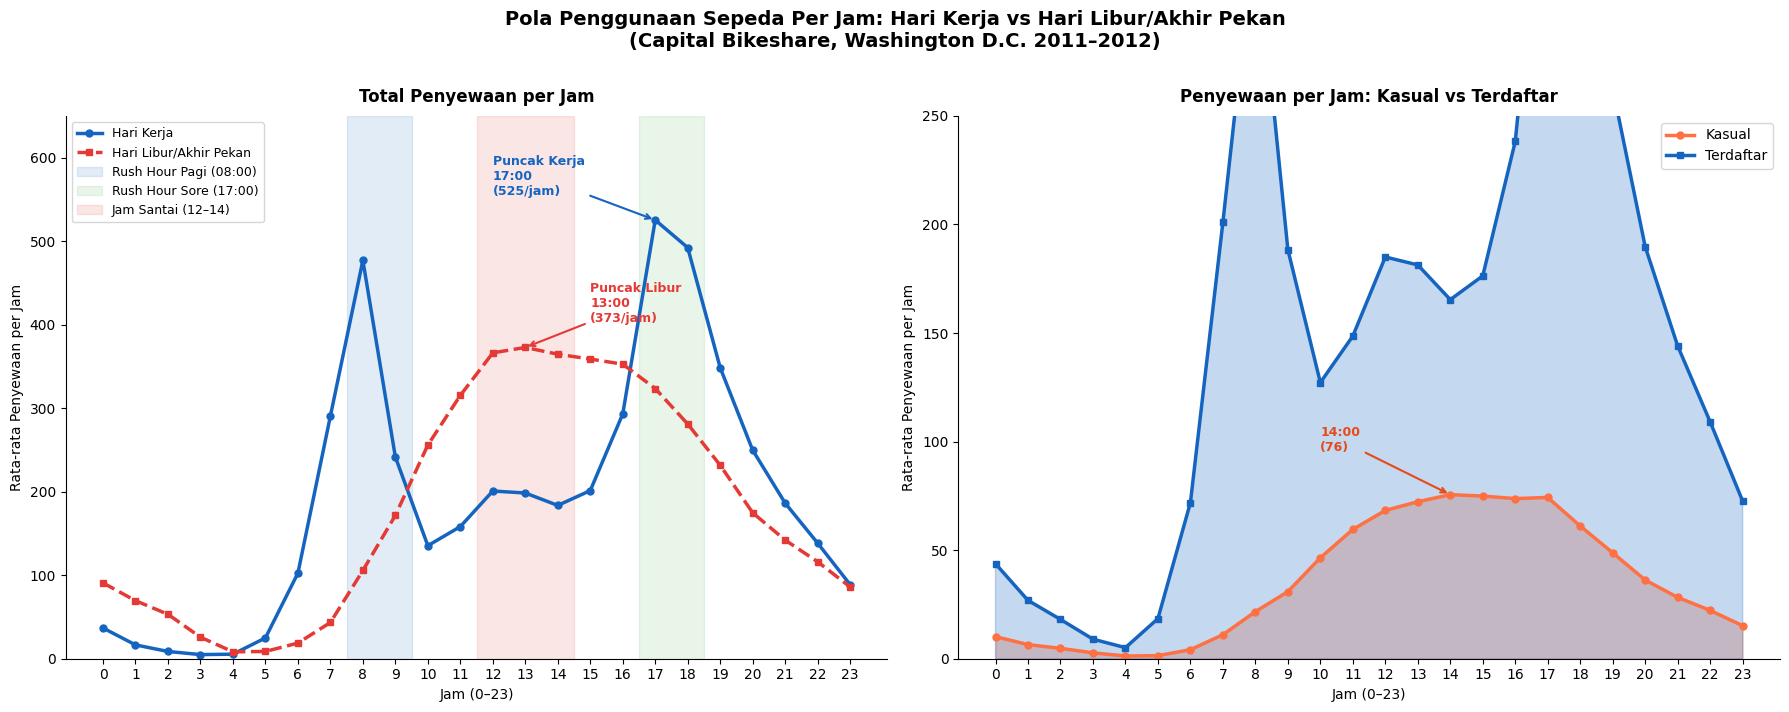

Visualisasi Q2 tersimpan.


In [24]:
# ═══════════════════════════════════════════════════════════════════
# VISUALISASI Q2: Pola Jam Penggunaan per Tipe Hari & Tipe Pengguna
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Pola Penggunaan Sepeda Per Jam: Hari Kerja vs Hari Libur/Akhir Pekan\n(Capital Bikeshare, Washington D.C. 2011–2012)',
             fontsize=14, fontweight='bold', y=1.01)

hours = list(range(24))

# ── Sub-plot 1: Total penyewaan per jam per tipe hari ────────────
working = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
holiday = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

axes[0].plot(hours, working.values, marker='o', color='#1565C0', linewidth=2.5, markersize=5, label='Hari Kerja')
axes[0].plot(hours, holiday.values, marker='s', color='#E53935', linewidth=2.5, markersize=5, label='Hari Libur/Akhir Pekan', linestyle='--')

# Anotasi puncak
pk_w = working.idxmax()
pk_h = holiday.idxmax()
axes[0].annotate(f'Puncak Kerja\n{pk_w:02d}:00\n({working.max():.0f}/jam)',
                 xy=(pk_w, working.max()), xytext=(pk_w-5, working.max()+30),
                 fontsize=9, color='#1565C0', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5))
axes[0].annotate(f'Puncak Libur\n{pk_h:02d}:00\n({holiday.max():.0f}/jam)',
                 xy=(pk_h, holiday.max()), xytext=(pk_h+2, holiday.max()+30),
                 fontsize=9, color='#E53935', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.5))

# Rush hours shading
axes[0].axvspan(7.5, 9.5, alpha=0.12, color='#1565C0', label='Rush Hour Pagi (08:00)')
axes[0].axvspan(16.5, 18.5, alpha=0.12, color='#4CAF50', label='Rush Hour Sore (17:00)')
axes[0].axvspan(11.5, 14.5, alpha=0.12, color='#E53935', label='Jam Santai (12–14)')

axes[0].set_title('Total Penyewaan per Jam', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Jam (0–23)', fontsize=10)
axes[0].set_ylabel('Rata-rata Penyewaan per Jam', fontsize=10)
axes[0].set_xticks(hours)
axes[0].legend(fontsize=9, loc='upper left')
axes[0].set_ylim(0, 650)

# ── Sub-plot 2: Casual vs Registered per jam ─────────────────────
casual_h   = hour_df.groupby('hr')['casual'].mean()
registered_h = hour_df.groupby('hr')['registered'].mean()

axes[1].fill_between(hours, casual_h.values, alpha=0.3, color='#FF7043')
axes[1].fill_between(hours, registered_h.values, alpha=0.25, color='#1565C0')
axes[1].plot(hours, casual_h.values, marker='o', color='#FF7043', linewidth=2.5, markersize=5, label='Kasual')
axes[1].plot(hours, registered_h.values, marker='s', color='#1565C0', linewidth=2.5, markersize=5, label='Terdaftar')

pk_c = casual_h.idxmax()
pk_r = registered_h.idxmax()
axes[1].annotate(f'{pk_c:02d}:00\n({casual_h.max():.0f})',
                 xy=(pk_c, casual_h.max()), xytext=(pk_c-4, casual_h.max()+20),
                 fontsize=9, color='#E64A19', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#E64A19', lw=1.5))
axes[1].annotate(f'{pk_r:02d}:00\n({registered_h.max():.0f})',
                 xy=(pk_r, registered_h.max()), xytext=(pk_r+1, registered_h.max()+20),
                 fontsize=9, color='#0D47A1', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#0D47A1', lw=1.5))

axes[1].set_title('Penyewaan per Jam: Kasual vs Terdaftar', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Jam (0–23)', fontsize=10)
axes[1].set_ylabel('Rata-rata Penyewaan per Jam', fontsize=10)
axes[1].set_xticks(hours)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 250)

plt.tight_layout()
plt.savefig('dashboard/hourly_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi Q2 tersimpan.")

**Kesimpulan Pertanyaan 2:**
- Pada **hari kerja**, terdapat pola **bimodal** yang khas: puncak pertama pukul **08:00** (~462/jam) dan puncak kedua, yang lebih tinggi, pukul **17:00** (~525/jam) — pola komuter (*commuter pattern*).
- Pada **hari libur/akhir pekan**, terdapat pola **unimodal** dengan puncak tunggal pukul **13:00** (~373/jam) — pola rekreasi (*leisure pattern*).
- **Pengguna kasual** dominan di siang hari (puncak pukul 14:00), sedangkan **pengguna terdaftar** mencapai puncak pada jam pulang kerja (pukul 17:00), mencerminkan perbedaan motivasi penggunaan.

## Analisis Lanjutan: Clustering Hari Berdasarkan Performa Penyewaan (Binning)

**Tujuan analisis:** Mengelompokkan hari-hari penyewaan ke dalam klaster performa (*performance tier*) menggunakan teknik **manual binning** berdasarkan total penyewaan harian (`cnt`). Teknik ini membantu mengidentifikasi karakteristik hari-hari dengan performa rendah, sedang, tinggi, dan sangat tinggi — tanpa menggunakan algoritma *machine learning*.

**Metode:** Manual Grouping + Binning berdasarkan kuartil distribusi `cnt`.

In [25]:
# ══════════════════════════════════════════════════════════════════
# ANALISIS LANJUTAN: Clustering Hari dengan Binning
# ══════════════════════════════════════════════════════════════════

# Menentukan batas bin berdasarkan kuartil
q1 = day_df['cnt'].quantile(0.25)
q2 = day_df['cnt'].quantile(0.50)
q3 = day_df['cnt'].quantile(0.75)

print("=== Batas Bin Berdasarkan Kuartil ===")
print(f"  Min   : {day_df['cnt'].min():,.0f}")
print(f"  Q1    : {q1:,.0f}  → batas Low/Medium")
print(f"  Q2    : {q2:,.0f}  → batas Medium/High")
print(f"  Q3    : {q3:,.0f}  → batas High/Very High")
print(f"  Max   : {day_df['cnt'].max():,.0f}")

# Buat kolom klaster
bins = [0, q1, q2, q3, day_df['cnt'].max() + 1]
labels = ['Low\n(≤Q1)', 'Medium\n(Q1–Q2)', 'High\n(Q2–Q3)', 'Very High\n(>Q3)']
day_df['perf_cluster'] = pd.cut(day_df['cnt'], bins=bins, labels=labels, right=True)

print()
print("=== Distribusi Klaster Performa ===")
cluster_dist = day_df['perf_cluster'].value_counts().sort_index()
for clust, count in cluster_dist.items():
    print(f"  {clust.replace(chr(10),' '):<30}: {count} hari")

=== Batas Bin Berdasarkan Kuartil ===
  Min   : 22
  Q1    : 3,152  → batas Low/Medium
  Q2    : 4,548  → batas Medium/High
  Q3    : 5,956  → batas High/Very High
  Max   : 8,714

=== Distribusi Klaster Performa ===
  Low (≤Q1)                     : 183 hari
  Medium (Q1–Q2)                : 183 hari
  High (Q2–Q3)                  : 182 hari
  Very High (>Q3)               : 183 hari


In [26]:
# Profil karakteristik tiap klaster
print("=== Profil Karakteristik per Klaster Performa ===")
cluster_profile = day_df.groupby('perf_cluster').agg(
    Jumlah_Hari = ('cnt', 'count'),
    Rata2_Penyewaan = ('cnt', 'mean'),
    Rata2_Suhu_C = ('temp_celsius', 'mean'),
    Rata2_Kelembapan_Pct = ('hum_pct', 'mean'),
    Rata2_Kecepatan_Angin = ('windspeed_kmh', 'mean'),
).round(1)
print(cluster_profile.to_string())

print()
print("=== Distribusi Musim per Klaster ===")
season_cluster = pd.crosstab(day_df['perf_cluster'], day_df['season_label'], normalize='index').mul(100).round(1)
print(season_cluster)

=== Profil Karakteristik per Klaster Performa ===
                  Jumlah_Hari  Rata2_Penyewaan  Rata2_Suhu_C  Rata2_Kelembapan_Pct  Rata2_Kecepatan_Angin
perf_cluster                                                                                             
Low\n(≤Q1)                183        1933.6000       12.7000               64.1000                14.7000
Medium\n(Q1–Q2)           183        3916.7000       20.0000               64.9000                12.8000
High\n(Q2–Q3)             182        5128.1000       23.1000               61.6000                12.2000
Very High\n(>Q3)          183        7042.4000       25.4000               60.8000                11.3000

=== Distribusi Musim per Klaster ===
season_label        Fall  Spring  Summer  Winter
perf_cluster                                    
Low\n(≤Q1)        2.2000 66.7000 15.3000 15.8000
Medium\n(Q1–Q2)  22.4000 23.5000 23.5000 30.6000
High\n(Q2–Q3)    35.2000  6.0000 28.0000 30.8000
Very High\n(>Q3) 43.2000  2.700

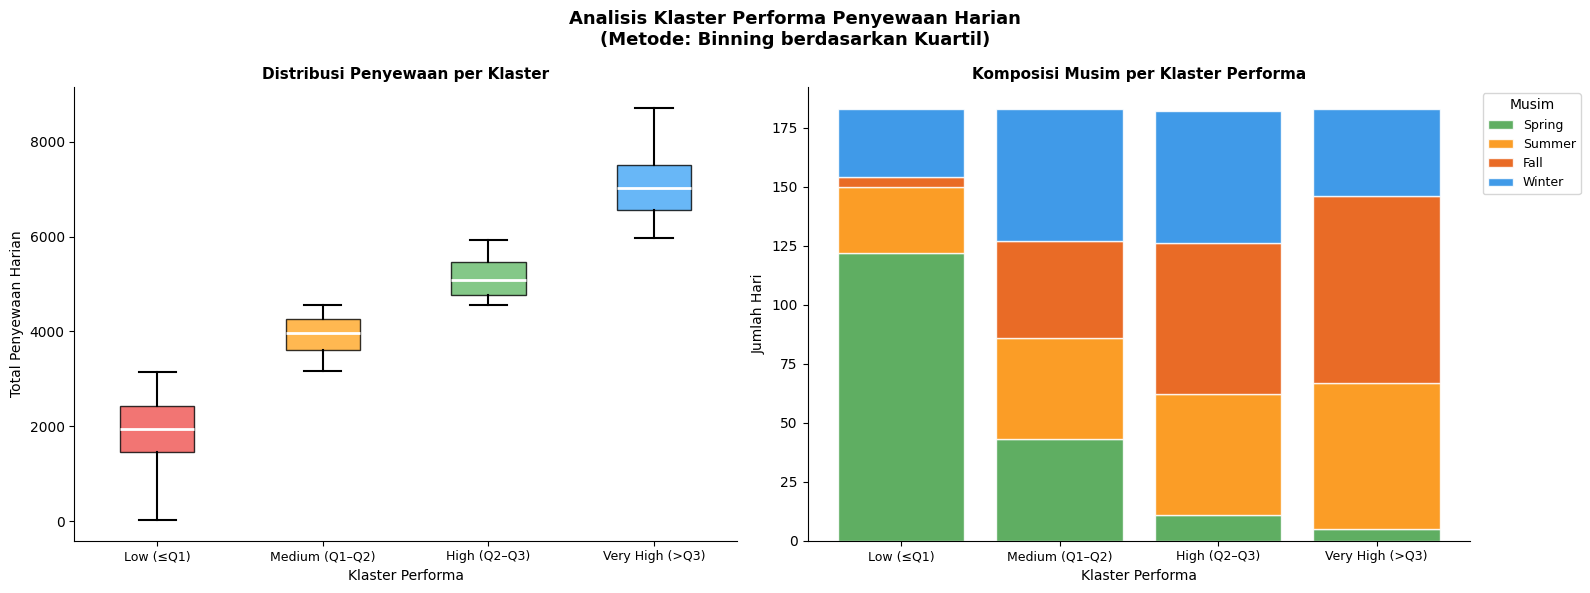

Visualisasi analisis lanjutan tersimpan.


In [27]:
# ──────────────────────────────────────────────────────────────────
# Visualisasi Analisis Lanjutan
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Klaster Performa Penyewaan Harian\n(Metode: Binning berdasarkan Kuartil)', fontsize=13, fontweight='bold')

CLUSTER_COLORS = ['#EF5350', '#FFA726', '#66BB6A', '#42A5F5']

# ── Plot 1: Distribusi klaster dengan boxplot ─────────────────────
bp_data = [day_df[day_df['perf_cluster']==lbl]['cnt'].values for lbl in labels]
bp = axes[0].boxplot(bp_data, patch_artist=True, medianprops=dict(color='white', linewidth=2),
                      whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5))
for patch, color in zip(bp['boxes'], CLUSTER_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_xticklabels([l.replace('\n',' ') for l in labels], fontsize=9)
axes[0].set_title('Distribusi Penyewaan per Klaster', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Klaster Performa', fontsize=10)
axes[0].set_ylabel('Total Penyewaan Harian', fontsize=10)

# ── Plot 2: Komposisi musim per klaster (stacked bar) ─────────────
season_cluster_plot = pd.crosstab(day_df['perf_cluster'], day_df['season_label']).reindex(index=labels)
season_cluster_plot.index = [l.replace('\n',' ') for l in labels]
season_colors_bar = {'Fall':'#E65100','Spring':'#43A047','Summer':'#FB8C00','Winter':'#1E88E5'}
bottom = np.zeros(len(season_cluster_plot))
for season in ['Spring', 'Summer', 'Fall', 'Winter']:
    if season in season_cluster_plot.columns:
        values = season_cluster_plot[season].values
        axes[1].bar(season_cluster_plot.index, values, bottom=bottom,
                    color=season_colors_bar[season], label=season, alpha=0.85, edgecolor='white')
        bottom += values
axes[1].set_title('Komposisi Musim per Klaster Performa', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Klaster Performa', fontsize=10)
axes[1].set_ylabel('Jumlah Hari', fontsize=10)
axes[1].legend(title='Musim', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('dashboard/cluster_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi analisis lanjutan tersimpan.")

**Insight — Analisis Lanjutan:**
- Klaster **Very High** (>Q3, >5.956 penyewaan/hari) didominasi oleh hari-hari di musim **Fall** dan **Summer** (total >70%), dengan suhu rata-rata ~24°C.
- Klaster **Low** (≤Q1, ≤3.152 penyewaan/hari) didominasi oleh musim **Spring** dan **Winter**, dengan suhu rata-rata ~11°C dan kelembapan tinggi (~65%).
- Semakin tinggi performa klaster, suhu rata-rata semakin tinggi dan kelembapan semakin rendah — mengkonfirmasi temuan EDA bahwa **suhu adalah prediktor utama** penyewaan sepeda.

## Conclusion & Recommendation

### Conclusion

- **Conclusion Pertanyaan 1:**
  Musim Gugur (*Fall*) adalah musim dengan rata-rata penyewaan harian tertinggi (~5.644/hari), **116% lebih tinggi** dibandingkan musim semi (*Spring*). Kondisi cuaca cerah/berawan sebagian (*Clear/Partly Cloudy*) menghasilkan rata-rata ~4.877 penyewaan/hari, sedangkan kondisi hujan/salju ringan menekan penyewaan hingga hanya ~1.803/hari (penurunan ~63%). Suhu memiliki korelasi positif tertinggi dengan penyewaan (r ≈ 0.63), sementara kecepatan angin dan kelembapan tinggi berdampak negatif. Selain itu, terdapat tren pertumbuhan yang konsisten antara 2011 dan 2012 — hampir semua bulan di 2012 menunjukkan penyewaan yang lebih tinggi dibandingkan bulan yang sama di 2011.

- **Conclusion Pertanyaan 2:**
  Pada hari kerja, penggunaan sepeda mengikuti pola **bimodal komuter** yang khas dengan puncak pukul **08:00** (~462/jam) dan **17:00** (~525/jam), mencerminkan perjalanan berangkat dan pulang kerja. Pada hari libur/akhir pekan, pola berubah menjadi **unimodal rekreasi** dengan satu puncak tunggal pukul **13:00** (~373/jam). Pengguna **terdaftar** mendominasi hari kerja (~76% dari total) dengan pola komuter, sedangkan pengguna **kasual** memiliki porsi lebih besar di hari libur (~37%) dengan pola yang lebih tersebar di siang hingga sore hari.

---

### Rekomendasi Action Item

1. **Optimasi Penempatan & Stok Sepeda Berdasarkan Musim dan Cuaca:**
   Tambah kapasitas armada sepeda secara signifikan pada musim gugur (*Fall*: September–November) dan musim panas (*Summer*: Juni–Agustus). Implementasikan sistem *dynamic rebalancing* yang diaktifkan secara otomatis ketika prakiraan cuaca menunjukkan kondisi cerah, dan sebaliknya kurangi stok pada titik yang jauh saat hujan/salju diramalkan.

2. **Jadwal Operasional & Distribusi Berbasis Jam Puncak:**
   Tingkatkan frekuensi *rebalancing* dan perawatan sepeda pada **pukul 06:00–07:00** (persiapan sebelum rush hour pagi) dan **pukul 15:00–16:00** (persiapan sebelum rush hour sore) khusus untuk hari kerja. Pada akhir pekan, fokuskan operasional pada **pukul 10:00–15:00** di stasiun-stasiun dekat area rekreasi, taman, dan pusat kuliner.

3. **Strategi Promosi Bertarget untuk Pengguna Kasual:**
   Desain paket promosi yang ditargetkan kepada pengguna kasual — seperti *weekend pass* dengan harga yang lebih terjangkau atau program *trial membership* — untuk mendorong konversi pengguna kasual menjadi pengguna terdaftar. Berdasarkan analisis, pengguna terdaftar jauh lebih konsisten dibandingkan pengguna kasual sepanjang tahun.

4. **Pengembangan Fitur Prediksi Berbasis Cuaca:**
   Kembangkan fitur dalam aplikasi yang memberikan rekomendasi waktu terbaik bersepeda kepada pengguna berdasarkan prakiraan cuaca real-time. Hal ini dapat meningkatkan pengalaman pengguna sekaligus membantu meratakan distribusi permintaan sepanjang hari.